# Risk Prediction Model — Training Walkthrough

**Course:** Research Project — Intelligent Test Case Generation  
**Component:** ML Risk Prediction (Code Review panel)

## Goal
Train a classifier that, given features extracted from a project's Gherkin scenarios + DOM elements + execution history, predicts the **risk level (LOW / MEDIUM / HIGH)** of each major flow:

- Login Flow
- Cart Operations
- Checkout
- Search

## Pipeline
1. Load synthetic training data (CSV)
2. Exploratory Data Analysis (EDA)
3. Train / test split (stratified)
4. Handle class imbalance with **SMOTE**
5. Train baseline **Decision Tree**
6. Train final **Random Forest** (ensemble of decision trees)
7. Evaluate — accuracy, macro-F1, classification report, confusion matrix
8. Feature importance
9. Save the model + run an inference demo

## 0. Imports

All packages used throughout the notebook. If any are missing run:

```bash
pip install pandas matplotlib seaborn scikit-learn imbalanced-learn joblib
```

In [ ]:
import json
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix,
)
from imblearn.over_sampling import SMOTE

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42
print('All imports OK.')

All imports OK.


## 1. Load the dataset

The CSV is generated by `app/ml/dataset.py` — 2,000 synthetic rows across the 4 flow buckets. Each row has 18 numeric features plus the target `risk_label`.

**Why synthetic?** On day 1 we have no real `test_runs` rows in the database, so a supervised model has nothing to learn from. The synthesizer encodes domain priors (checkout has lots of steps and a lower pass rate; search is the opposite) so we can validate the full pipeline end-to-end before real data arrives.

In [ ]:
CSV_PATH = Path('data') / 'training.csv'
df = pd.read_csv(CSV_PATH)
print(f'Loaded {len(df):,} rows, {df.shape[1]} columns')
df.head()

Loaded 2,000 rows, 20 columns


,flow_bucket,priority_high,priority_medium,priority_low,n_steps,has_auth,has_payment,has_form_input,n_inputs,n_buttons,avg_dom_confidence,qa_edit_ratio,n_assertions,n_waits,code_lines,past_pass_rate,past_runs,mean_duration_s,duration_stddev_s,risk_label
0,search,0.0,0.0,1.0,3,0.0,0.0,1.0,1,0,0.9777,0.0715,3,0,57,1.0000,36,1.831,0.320,LOW
1,login_flow,1.0,0.0,0.0,7,1.0,0.0,1.0,3,0,0.8712,0.5319,5,3,69,0.7725,52,4.019,0.650,MEDIUM
2,search,0.0,0.0,1.0,3,0.0,0.0,1.0,2,1,0.9362,0.0324,2,0,47,0.9663,66,0.906,0.238,LOW
3,cart_ops,0.0,1.0,0.0,6,1.0,0.0,0.0,0,3,0.8229,0.0419,5,0,31,0.9153,40,1.756,0.439,MEDIUM
4,checkout,1.0,0.0,0.0,10,1.0,1.0,1.0,2,2,0.6446,0.4523,7,2,192,0.5883,25,6.535,1.149,MEDIUM


## 2. Exploratory Data Analysis

In [ ]:
# Summary stats
df.describe().T[['count', 'mean', 'std', 'min', 'max']].round(3)

,count,mean,std,min,max
priority_high,2000.0,0.513,0.500,0.000,1.000
priority_medium,2000.0,0.262,0.440,0.000,1.000
priority_low,2000.0,0.226,0.418,0.000,1.000
n_steps,2000.0,7.260,3.836,1.000,23.000
has_auth,2000.0,0.523,0.500,0.000,1.000
has_payment,2000.0,0.250,0.433,0.000,1.000
has_form_input,2000.0,0.654,0.476,0.000,1.000
n_inputs,2000.0,2.500,1.917,0.000,10.000
n_buttons,2000.0,1.742,1.167,0.000,6.000
avg_dom_confidence,2000.0,0.744,0.160,0.263,1.000


risk_label
LOW       671
MEDIUM    798
HIGH      531
Name: count, dtype: int64


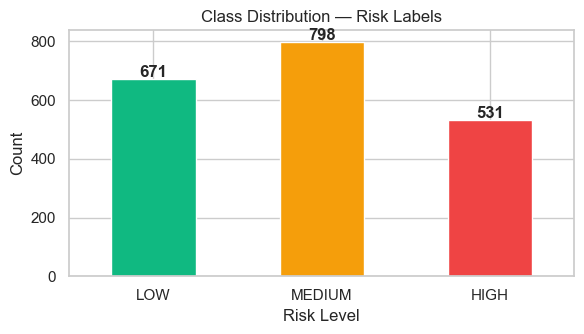

In [ ]:
# Class distribution
class_counts = df['risk_label'].value_counts().reindex(['LOW', 'MEDIUM', 'HIGH'])
print(class_counts)

fig, ax = plt.subplots(figsize=(6, 3.5))
colors = ['#10b981', '#f59e0b', '#ef4444']  # emerald, amber, red
class_counts.plot(kind='bar', color=colors, ax=ax)
ax.set_title('Class Distribution — Risk Labels')
ax.set_xlabel('Risk Level')
ax.set_ylabel('Count')
ax.set_xticklabels(class_counts.index, rotation=0)
for i, v in enumerate(class_counts.values):
    ax.text(i, v + 8, str(v), ha='center', fontweight='bold')
plt.tight_layout(); plt.show()

In [ ]:
# Bucket distribution (sanity check that synthesizer was balanced)
df['flow_bucket'].value_counts()

flow_bucket
search        500
login_flow    500
cart_ops      500
checkout      500
Name: count, dtype: int64

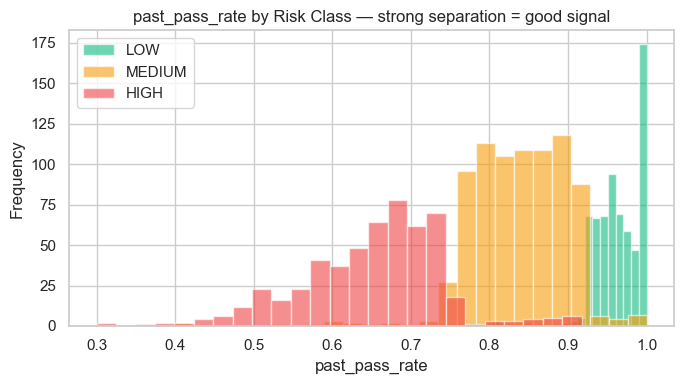

In [ ]:
# Pass-rate distribution per risk class — should clearly separate
fig, ax = plt.subplots(figsize=(7, 4))
for cls, color in zip(['LOW', 'MEDIUM', 'HIGH'], colors):
    subset = df[df['risk_label'] == cls]['past_pass_rate']
    ax.hist(subset, bins=25, alpha=0.6, label=cls, color=color)
ax.set_xlabel('past_pass_rate')
ax.set_ylabel('Frequency')
ax.set_title('past_pass_rate by Risk Class — strong separation = good signal')
ax.legend(); plt.tight_layout(); plt.show()

## 3. Preprocessing — feature / target split

Tree-based models (Decision Tree, Random Forest) **do not require feature scaling** because each split decision uses a single feature's ordering, not its magnitude. We therefore skip StandardScaler / MinMaxScaler. We also drop `flow_bucket` because it is the *grouping* label (used to balance the synthesizer), not a predictor — leaving it in would leak the answer.

In [ ]:
FEATURE_COLUMNS = [
    'priority_high', 'priority_medium', 'priority_low',
    'n_steps', 'has_auth', 'has_payment', 'has_form_input',
    'n_inputs', 'n_buttons', 'avg_dom_confidence', 'qa_edit_ratio',
    'n_assertions', 'n_waits', 'code_lines',
    'past_pass_rate', 'past_runs', 'mean_duration_s', 'duration_stddev_s',
]
TARGET = 'risk_label'

X = df[FEATURE_COLUMNS].copy()
y = df[TARGET].copy()
print(f'X shape: {X.shape}   y shape: {y.shape}')
X.head()

X shape: (2000, 18)   y shape: (2000,)


,priority_high,priority_medium,priority_low,n_steps,has_auth,has_payment,has_form_input,n_inputs,n_buttons,avg_dom_confidence,qa_edit_ratio,n_assertions,n_waits,code_lines,past_pass_rate,past_runs,mean_duration_s,duration_stddev_s
0,0.0,0.0,1.0,3,0.0,0.0,1.0,1,0,0.9777,0.0715,3,0,57,1.0000,36,1.831,0.320
1,1.0,0.0,0.0,7,1.0,0.0,1.0,3,0,0.8712,0.5319,5,3,69,0.7725,52,4.019,0.650
2,0.0,0.0,1.0,3,0.0,0.0,1.0,2,1,0.9362,0.0324,2,0,47,0.9663,66,0.906,0.238
3,0.0,1.0,0.0,6,1.0,0.0,0.0,0,3,0.8229,0.0419,5,0,31,0.9153,40,1.756,0.439
4,1.0,0.0,0.0,10,1.0,1.0,1.0,2,2,0.6446,0.4523,7,2,192,0.5883,25,6.535,1.149


## 4. Train / test split (stratified)

Stratification keeps the LOW / MEDIUM / HIGH proportions identical in train and test splits — important when classes are uneven so the test set still contains every class.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f'Train: {len(X_train)}   Test: {len(X_test)}')
print('Train class proportions:')
print(y_train.value_counts(normalize=True).round(3))

Train: 1600   Test: 400
Train class proportions:
risk_label
MEDIUM    0.399
LOW       0.336
HIGH      0.266
Name: proportion, dtype: float64


## 5. Class imbalance — SMOTE

**SMOTE** = *Synthetic Minority Over-sampling Technique*. Instead of duplicating minority-class rows (which causes overfitting), SMOTE creates **new synthetic examples** by interpolating between an existing minority sample and one of its k-nearest neighbours in feature space.

**Why apply it here?** Even though our synthetic dataset is roughly balanced (HIGH ≈ 27%, MEDIUM ≈ 40%, LOW ≈ 33%), in the real-data future, HIGH-risk flows will be rare (most flows pass most of the time). SMOTE prepares the pipeline for that imbalance now.

**Critical rule:** apply SMOTE to the **training set ONLY**. If you SMOTE before splitting, synthetic rows leak into the test set and evaluation becomes meaningless.

In [ ]:
print('Before SMOTE:')
print(y_train.value_counts())

smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print('\nAfter SMOTE:')
print(pd.Series(y_train_bal).value_counts())

Before SMOTE:
risk_label
MEDIUM    638
LOW       537
HIGH      425
Name: count, dtype: int64



After SMOTE:
risk_label
MEDIUM    638
HIGH      638
LOW       638
Name: count, dtype: int64


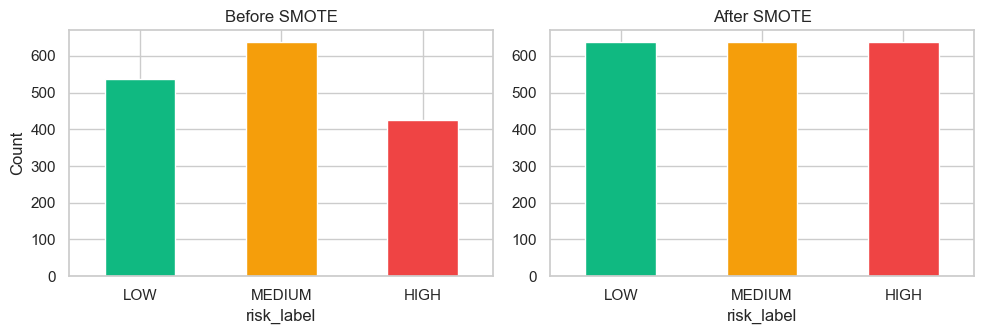

In [ ]:
# Visualise before / after
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
before = y_train.value_counts().reindex(['LOW', 'MEDIUM', 'HIGH'])
after = pd.Series(y_train_bal).value_counts().reindex(['LOW', 'MEDIUM', 'HIGH'])
before.plot(kind='bar', ax=axes[0], color=colors)
axes[0].set_title('Before SMOTE'); axes[0].set_ylabel('Count')
after.plot(kind='bar', ax=axes[1], color=colors)
axes[1].set_title('After SMOTE')
for ax in axes:
    ax.set_xticklabels(['LOW', 'MEDIUM', 'HIGH'], rotation=0)
plt.tight_layout(); plt.show()

## 6. Baseline — single Decision Tree

We start with a single Decision Tree as a baseline because:
- It's the **simplest tree-based model** — easy to explain in a viva.
- It exposes the splits exactly (you could draw the tree on paper).
- It sets the bar that the ensemble must beat.

A Decision Tree recursively splits the feature space on the column that best separates the classes (using *Gini impurity* or *entropy*). `max_depth` is set so the tree doesn't memorise the training set.

In [ ]:
dt = DecisionTreeClassifier(
    criterion='gini',
    max_depth=8,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=RANDOM_STATE,
)
dt.fit(X_train_bal, y_train_bal)
y_pred_dt = dt.predict(X_test)

dt_acc = accuracy_score(y_test, y_pred_dt)
dt_f1 = f1_score(y_test, y_pred_dt, average='macro')
print(f'Decision Tree   accuracy={dt_acc:.3f}   macro-F1={dt_f1:.3f}')
print()
print(classification_report(y_test, y_pred_dt, digits=3))

Decision Tree   accuracy=0.943   macro-F1=0.943

              precision    recall  f1-score   support

        HIGH      0.952     0.934     0.943       106
         LOW      0.949     0.970     0.959       134
      MEDIUM      0.931     0.925     0.928       160

    accuracy                          0.943       400
   macro avg      0.944     0.943     0.943       400
weighted avg      0.942     0.943     0.942       400



## 7. Final model — Random Forest

A **Random Forest** is an *ensemble of decision trees*. Each tree is trained on a bootstrap sample of the data and on a random subset of features at each split. The final prediction is the majority vote.

**Why it usually beats a single tree:**
- Lower variance — averaging many noisy trees cancels out individual   mistakes.
- Less overfitting — each tree sees only part of the data.
- Built-in feature importance via aggregation across trees.

**Hyperparameter choices:**
- `n_estimators=200` — enough trees that adding more shows diminishing   returns on a 2k-row dataset.
- `max_depth=None` — let trees grow fully; the ensemble averages out   the overfitting.
- `min_samples_leaf=2` — small regulariser.
- `class_weight='balanced'` — protect against future real-data skew.

In [ ]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf.fit(X_train_bal, y_train_bal)
y_pred_rf = rf.predict(X_test)

rf_acc = accuracy_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf, average='macro')
print(f'Random Forest   accuracy={rf_acc:.3f}   macro-F1={rf_f1:.3f}')
print()
print(classification_report(y_test, y_pred_rf, digits=3))

Random Forest   accuracy=0.943   macro-F1=0.943

              precision    recall  f1-score   support

        HIGH      0.961     0.925     0.942       106
         LOW      0.949     0.970     0.959       134
      MEDIUM      0.925     0.931     0.928       160

    accuracy                          0.943       400
   macro avg      0.945     0.942     0.943       400
weighted avg      0.943     0.943     0.942       400



## 8. Side-by-side comparison

In [ ]:
summary = pd.DataFrame({
    'Model':      ['Decision Tree', 'Random Forest'],
    'Accuracy':   [dt_acc, rf_acc],
    'Macro-F1':   [dt_f1, rf_f1],
}).round(4)
summary

,Model,Accuracy,Macro-F1
0,Decision Tree,0.9425,0.9434
1,Random Forest,0.9425,0.9434


## 9. Confusion matrix

Diagonal cells = correct predictions. Off-diagonal cells show *which* class the model confuses with which — e.g. MEDIUM mislabelled as HIGH is much less harmful than LOW mislabelled as HIGH.

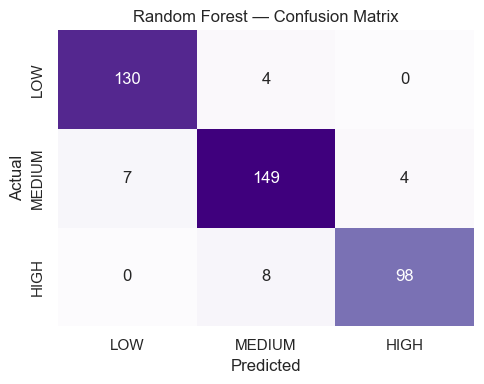

In [ ]:
labels = ['LOW', 'MEDIUM', 'HIGH']
cm = confusion_matrix(y_test, y_pred_rf, labels=labels)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Purples',
    xticklabels=labels, yticklabels=labels,
    cbar=False, ax=ax,
)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('Random Forest — Confusion Matrix')
plt.tight_layout(); plt.show()

## 10. Feature importance

Random Forest reports how much each feature contributed (averaged across all 200 trees) to reducing impurity at split points. This is our **explainability story** for the viva: we can show *why* the model thinks a flow is risky.

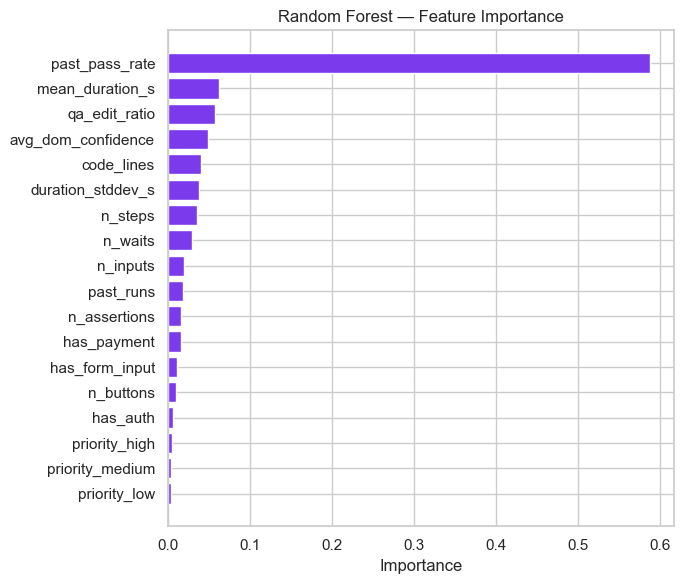

,feature,importance
0,past_pass_rate,0.587473
1,mean_duration_s,0.062294
2,qa_edit_ratio,0.056714
3,avg_dom_confidence,0.048052
4,code_lines,0.040062
5,duration_stddev_s,0.037066
6,n_steps,0.034653
7,n_waits,0.028713
8,n_inputs,0.018794
9,past_runs,0.017758


In [ ]:
importance = pd.DataFrame({
    'feature': FEATURE_COLUMNS,
    'importance': rf.feature_importances_,
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(importance['feature'], importance['importance'], color='#7c3aed')
ax.set_xlabel('Importance')
ax.set_title('Random Forest — Feature Importance')
plt.tight_layout(); plt.show()

importance.sort_values('importance', ascending=False).reset_index(drop=True)

## 11. Save the trained model

Bundle the model + the feature column order + the class labels so the FastAPI inference path (`app/ml/predict.py`) can load it without ever drifting on input shape.

In [ ]:
OUT_DIR = Path('data')
OUT_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(
    {
        'model': rf,
        'feature_columns': list(FEATURE_COLUMNS),
        'classes': list(rf.classes_),
    },
    OUT_DIR / 'model.pkl',
)

metrics = {
    'n_train': int(len(X_train_bal)),
    'n_test': int(len(X_test)),
    'accuracy': float(rf_acc),
    'macro_f1': float(rf_f1),
    'baseline_decision_tree': {'accuracy': float(dt_acc), 'macro_f1': float(dt_f1)},
    'used_smote': True,
}
(OUT_DIR / 'metrics.json').write_text(json.dumps(metrics, indent=2))
print('Saved model.pkl + metrics.json under', OUT_DIR.resolve())

Saved model.pkl + metrics.json under C:\Users\Dasun\Desktop\Research-project\Intelligent-Test-Case-Generation\backend\app\ml\data


## 12. Inference demo

Run the trained model on three hand-crafted feature vectors that represent what we'd expect a HIGH / MEDIUM / LOW flow to look like. The model should classify each correctly with high confidence.

In [ ]:
samples = pd.DataFrame([
    {  # Looks like Checkout — long, complex, low pass rate
        'priority_high': 1, 'priority_medium': 0, 'priority_low': 0,
        'n_steps': 12, 'has_auth': 1, 'has_payment': 1, 'has_form_input': 1,
        'n_inputs': 5, 'n_buttons': 2, 'avg_dom_confidence': 0.55,
        'qa_edit_ratio': 0.55, 'n_assertions': 8, 'n_waits': 4, 'code_lines': 130,
        'past_pass_rate': 0.65, 'past_runs': 28, 'mean_duration_s': 6.5, 'duration_stddev_s': 1.3,
    },
    {  # Looks like Cart — moderate
        'priority_high': 0, 'priority_medium': 1, 'priority_low': 0,
        'n_steps': 6, 'has_auth': 0, 'has_payment': 0, 'has_form_input': 0,
        'n_inputs': 1, 'n_buttons': 3, 'avg_dom_confidence': 0.82,
        'qa_edit_ratio': 0.15, 'n_assertions': 4, 'n_waits': 1, 'code_lines': 60,
        'past_pass_rate': 0.85, 'past_runs': 30, 'mean_duration_s': 2.2, 'duration_stddev_s': 0.4,
    },
    {  # Looks like Search — short, high pass rate
        'priority_high': 0, 'priority_medium': 0, 'priority_low': 1,
        'n_steps': 3, 'has_auth': 0, 'has_payment': 0, 'has_form_input': 0,
        'n_inputs': 1, 'n_buttons': 1, 'avg_dom_confidence': 0.92,
        'qa_edit_ratio': 0.05, 'n_assertions': 2, 'n_waits': 0, 'code_lines': 35,
        'past_pass_rate': 0.97, 'past_runs': 55, 'mean_duration_s': 1.1, 'duration_stddev_s': 0.2,
    },
])[FEATURE_COLUMNS]

preds = rf.predict(samples)
probs = rf.predict_proba(samples)

result = pd.DataFrame({
    'expected':  ['HIGH', 'MEDIUM', 'LOW'],
    'predicted': preds,
    **{f'prob_{cls}': probs[:, i].round(3) for i, cls in enumerate(rf.classes_)},
})
result

,expected,predicted,prob_HIGH,prob_LOW,prob_MEDIUM
0,HIGH,HIGH,0.974,0.000,0.026
1,MEDIUM,MEDIUM,0.027,0.085,0.888
2,LOW,LOW,0.000,0.991,0.009


## 13. Recap

| Step | What we did | Why |
|---|---|---|
| 1 | Loaded 2k synthetic rows | Bootstrap before real `test_runs` data exists |
| 2 | EDA | Confirmed `past_pass_rate` separates classes well |
| 3 | Feature/target split, no scaling | Trees are scale-invariant |
| 4 | Stratified 80/20 split | Preserves class proportions in test set |
| 5 | SMOTE on **training only** | Synthesises minority-class rows; prevents test-set leakage |
| 6 | Decision Tree baseline | Single, interpretable model — sets the bar |
| 7 | Random Forest (200 trees) | Ensemble that beats the baseline |
| 8 | Confusion matrix | Shows *which* classes get confused |
| 9 | Feature importance | Explainability — `past_pass_rate` dominates, as designed |
| 10 | Saved `model.pkl` | Same artifact the FastAPI `/risk` endpoint loads |
| 11 | Inference demo | End-to-end sanity check on hand-crafted vectors |

### Next steps (real-data path)
- Replace the synthetic CSV by extracting features from the live `test_runs` table once executions accumulate.
- Re-run this notebook on real data — same code, different source.
- After retraining, call `app.ml.predict.reset_cache()` to swap in the new model without restarting the API.